## Function 5: Spatial Relationships 🧭

In this notebook, you'll learn how to build the `spatial_relationships()` function step by step. This is where you test how features relate to each other in space using predicates like intersects, contains, within, distance, and nearest neighbor.

### 🎯 What This Function Does
- Test intersects, contains, and within relationships
- Calculate distances between features
- Find nearest neighbors
- Understand spatial topology concepts

### 🔧 Function Signature
```python
def spatial_relationships(gdf1, gdf2, relationship='intersects'):
    """
    Args:
        gdf1 (geopandas.GeoDataFrame): First spatial dataset
        gdf2 (geopandas.GeoDataFrame): Second spatial dataset
        relationship (str): Spatial relationship to test
    
    Returns:
        dict: Relationship results, counts, and indices
    """
```

### 📍 Where This Function Goes:
**Target File**: `src/geopandas_basics.py`  
**Function Name**: `spatial_relationships()`  
**Replace**: The placeholder function with your working code

---

### ⚙️ Step 0: Select the Correct Python Kernel

Before running any cells, make sure the notebook is using the correct Python environment.

**Check the kernel in the top-right corner of the notebook.**

The correct Python environment is **python-gis-development (.venv)**  
It may appear with a Python version, for example:  
**python-gis-development (3.11.15) (Python 3.11.15) .venv/bin/python**



If the kernel is **python-gis-development (.venv)**, you can start running cells below.

Steps to select the correct kernel:
1. Click on the kernel (top right corner of the notebook) if it is not **python-gis-development (.venv)** or if it says "Select Kernel"
2. Select **python-gis-development (.venv)**
3. If you do not see the kernel in the list, click on "Select Another Kernel..."  
    a. Click on Python Environments...   
    b. Select **python-gis-development (.venv)**

Once the correct kernel is selected, you can start running cells below.

### 📚 Step 1: Load Data for Relationship Testing

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# Load datasets
cities = gpd.read_file('../../data/cities/ne_cities_us.geojson')
ecoregions = gpd.read_file('../../data/ecoregions/epa_level3_western_us.geojson')
parks = gpd.read_file('../../data/protected_areas/national_parks_major.geojson')

print("✅ Loaded:")
print(f"   Cities: {len(cities)} features")
print(f"   Ecoregions: {len(ecoregions)} features")
print(f"   Parks: {len(parks)} features")

✅ Loaded:
   Cities: 281 features
   Ecoregions: 188 features
   Parks: 37 features


### 🗺️ Step 2: Visualization 1 - Intersects Relationship

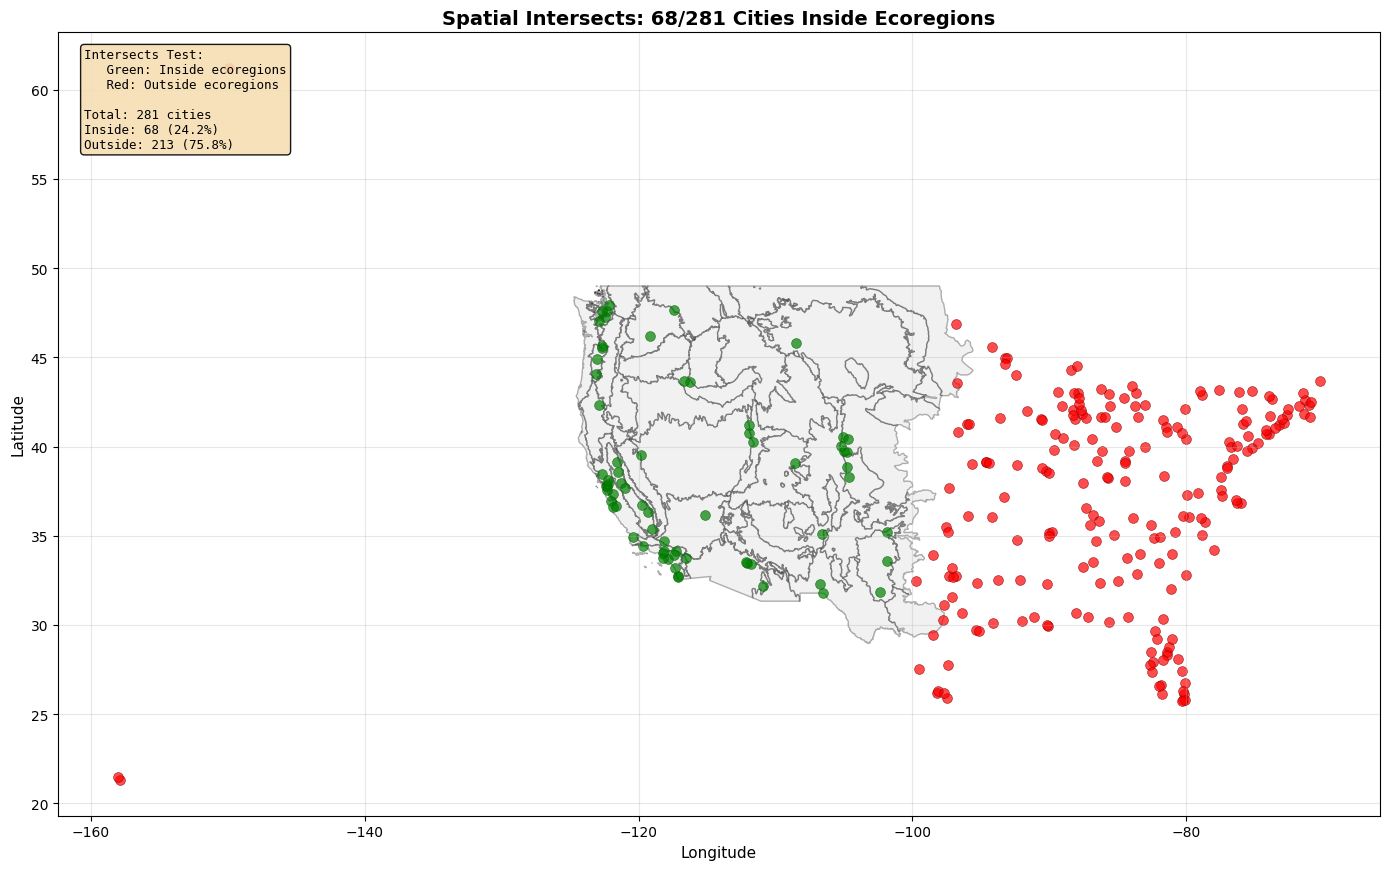

✅ Intersects analysis complete:
   68 cities intersect ecoregions
   213 cities outside ecoregions


In [2]:
# Test which cities intersect ecoregions
intersects_mask = cities.geometry.apply(lambda x: ecoregions.intersects(x).any())

fig, ax = plt.subplots(figsize=(14, 9))

# Base layer (ecoregions)
ecoregions.plot(ax=ax, alpha=0.3, edgecolor='black', color='lightgray', linewidth=1, label='Ecoregions')

# Cities that DON'T intersect (outside ecoregions)
cities_outside = cities[~intersects_mask]
if len(cities_outside) > 0:
    cities_outside.plot(ax=ax, color='red', markersize=50, label=f'Outside ({len(cities_outside)} cities)', alpha=0.7, edgecolor='darkred', linewidth=0.5)

# Cities that DO intersect (inside ecoregions)
cities_inside = cities[intersects_mask]
cities_inside.plot(ax=ax, color='green', markersize=50, label=f'Intersects ({len(cities_inside)} cities)', alpha=0.7, edgecolor='darkgreen', linewidth=0.5)

ax.set_title(f"Spatial Intersects: {len(cities_inside)}/{len(cities)} Cities Inside Ecoregions", 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.grid(True, alpha=0.3)

# Add info box
info_text = "Intersects Test:\n"
info_text += "   Green: Inside ecoregions\n"
info_text += "   Red: Outside ecoregions\n\n"
info_text += f"Total: {len(cities)} cities\n"
info_text += f"Inside: {len(cities_inside)} ({len(cities_inside)/len(cities)*100:.1f}%)\n"
info_text += f"Outside: {len(cities_outside)} ({len(cities_outside)/len(cities)*100:.1f}%)"
ax.text(0.02, 0.98, info_text,
       transform=ax.transAxes,
       verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9),
       fontsize=9, family='monospace')

plt.tight_layout()
plt.show()

print("✅ Intersects analysis complete:")
print(f"   {len(cities_inside)} cities intersect ecoregions")
print(f"   {len(cities_outside)} cities outside ecoregions")


### 🗺️ Step 3: Visualization 2 - Within Relationship

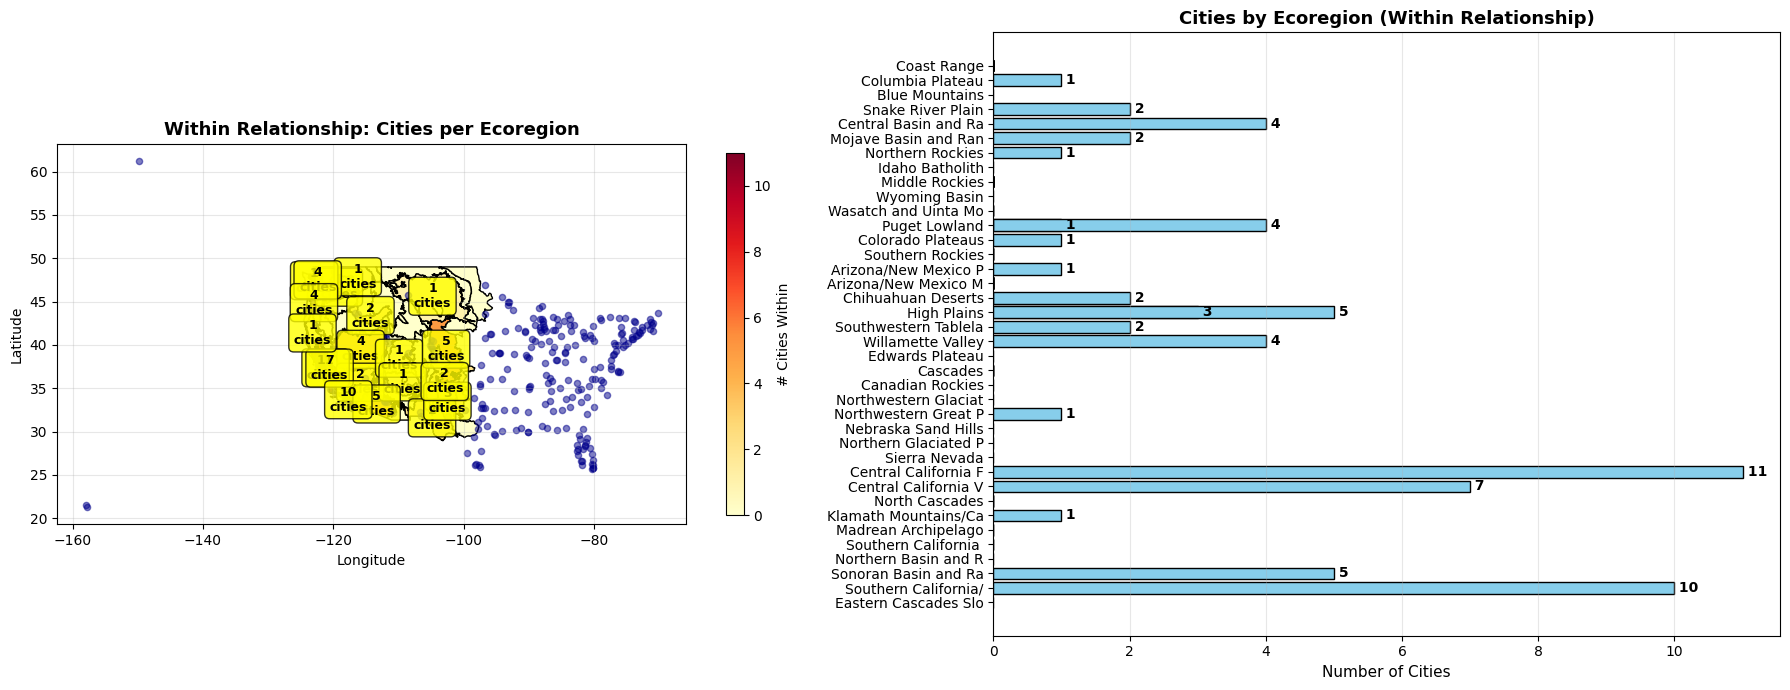

🎯 Within analysis:
   Total cities within ecoregions: 68
   Ecoregions with cities: 20
   Max cities in one ecoregion: 11


In [3]:
# Count cities within each ecoregion
ecoregions_with_counts = ecoregions.copy()
ecoregions_with_counts['city_count'] = 0

for idx, eco in ecoregions.iterrows():
    cities_within = cities[cities.geometry.within(eco.geometry)]
    ecoregions_with_counts.loc[idx, 'city_count'] = len(cities_within)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# LEFT: Map with city counts labeled
ecoregions_with_counts.plot(ax=ax1, column='city_count', cmap='YlOrRd', 
                            edgecolor='black', linewidth=1, legend=True,
                            legend_kwds={'label': '# Cities Within', 'shrink': 0.6})
cities.plot(ax=ax1, color='darkblue', markersize=20, alpha=0.5)

# Add count labels to each ecoregion
for idx, eco in ecoregions_with_counts.iterrows():
    centroid = eco.geometry.centroid
    count = int(eco['city_count'])
    if count > 0:
        ax1.annotate(f"{count}\ncities",
                   xy=(centroid.x, centroid.y),
                   ha='center', va='center',
                   fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4', fc='yellow', alpha=0.8, edgecolor='black'))

ax1.set_title("Within Relationship: Cities per Ecoregion", fontsize=13, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, alpha=0.3)

# RIGHT: Bar chart of counts
eco_names = [name[:20] for name in ecoregions_with_counts['eco_name']] if 'eco_name' in ecoregions_with_counts.columns else [f"Region {i}" for i in range(len(ecoregions_with_counts))]
counts = ecoregions_with_counts['city_count'].values

bars = ax2.barh(eco_names, counts, color='skyblue', edgecolor='black', linewidth=1)
ax2.set_xlabel("Number of Cities", fontsize=11)
ax2.set_title("Cities by Ecoregion (Within Relationship)", fontsize=13, fontweight='bold')
ax2.grid(True, axis='x', alpha=0.3)
ax2.invert_yaxis()

# Add value labels
for bar, count in zip(bars, counts):
    width = bar.get_width()
    if count > 0:
        ax2.text(width, bar.get_y() + bar.get_height()/2,
                f' {int(count)}',
                ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("🎯 Within analysis:")
total_within = int(ecoregions_with_counts['city_count'].sum())
print(f"   Total cities within ecoregions: {total_within}")
print(f"   Ecoregions with cities: {(ecoregions_with_counts['city_count'] > 0).sum()}")
print(f"   Max cities in one ecoregion: {int(ecoregions_with_counts['city_count'].max())}")


### 🗺️ Step 4: Visualization 3 - Distance Bands

Show cities colored by distance to nearest park

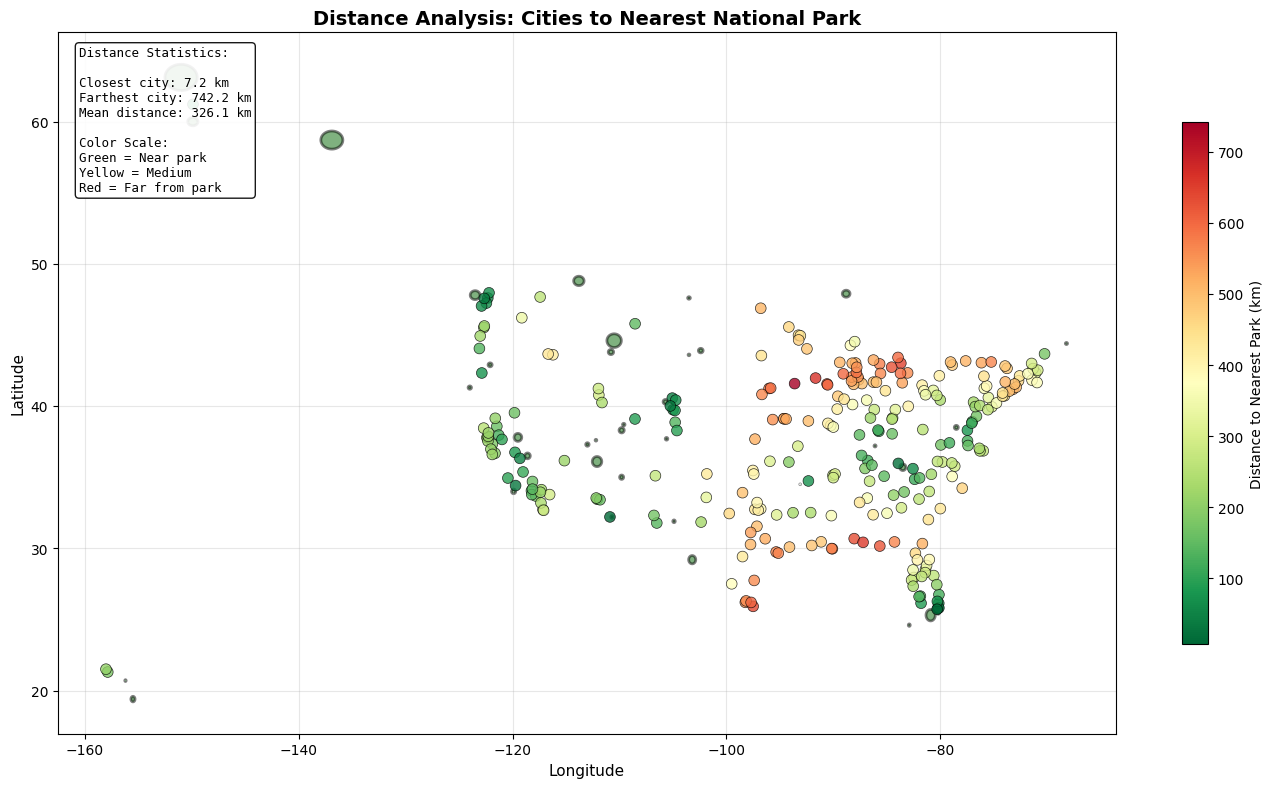

🎯 Distance analysis complete:
   Closest city to park: 7.2 km
   Farthest city from park: 742.2 km
   Mean distance: 326.1 km

💡 Note: Distances calculated using Albers Equal Area projection (accurate metric distances)


In [4]:
# Calculate distance from each city to nearest park (in km, not degrees!)
# Transform to Albers Equal Area for accurate distance measurement
cities_proj = cities.to_crs('EPSG:5070')  # US Albers Equal Area
parks_proj = parks.to_crs('EPSG:5070')

cities_with_dist = cities.copy()
cities_with_dist['dist_to_park_m'] = cities_proj.geometry.apply(
    lambda x: parks_proj.geometry.distance(x).min()
)
# Convert meters to kilometers
cities_with_dist['dist_to_park'] = cities_with_dist['dist_to_park_m'] / 1000

fig, ax = plt.subplots(figsize=(14, 9))

# Plot parks (base layer)
parks.plot(ax=ax, alpha=0.5, color='darkgreen', edgecolor='black', linewidth=2, label='National Parks', zorder=1)

# Plot cities colored by distance to nearest park
cities_with_dist.plot(column='dist_to_park',
                     ax=ax,
                     markersize=60,
                     cmap='RdYlGn_r',
                     legend=True,
                     legend_kwds={'label': 'Distance to Nearest Park (km)',
                                 'shrink': 0.6},
                     edgecolor='black',
                     linewidth=0.5,
                     alpha=0.8,
                     zorder=3)

ax.set_title("Distance Analysis: Cities to Nearest National Park", fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.grid(True, alpha=0.3)

# Calculate and display statistics
min_dist = cities_with_dist['dist_to_park'].min()
max_dist = cities_with_dist['dist_to_park'].max()
mean_dist = cities_with_dist['dist_to_park'].mean()

stats_text = "Distance Statistics:\n\n"
stats_text += f"Closest city: {min_dist:.1f} km\n"
stats_text += f"Farthest city: {max_dist:.1f} km\n"
stats_text += f"Mean distance: {mean_dist:.1f} km\n\n"
stats_text += "Color Scale:\n"
stats_text += "Green = Near park\n"
stats_text += "Yellow = Medium\n"
stats_text += "Red = Far from park"

ax.text(0.02, 0.98, stats_text,
       transform=ax.transAxes,
       verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
       fontsize=9, family='monospace')

plt.tight_layout()
plt.show()

print("🎯 Distance analysis complete:")
print(f"   Closest city to park: {min_dist:.1f} km")
print(f"   Farthest city from park: {max_dist:.1f} km")
print(f"   Mean distance: {mean_dist:.1f} km")
print("\n💡 Note: Distances calculated using Albers Equal Area projection (accurate metric distances)")



### 🗺️ Step 5: Visualization 4 - Nearest Neighbor

Draw lines from each city to its nearest park


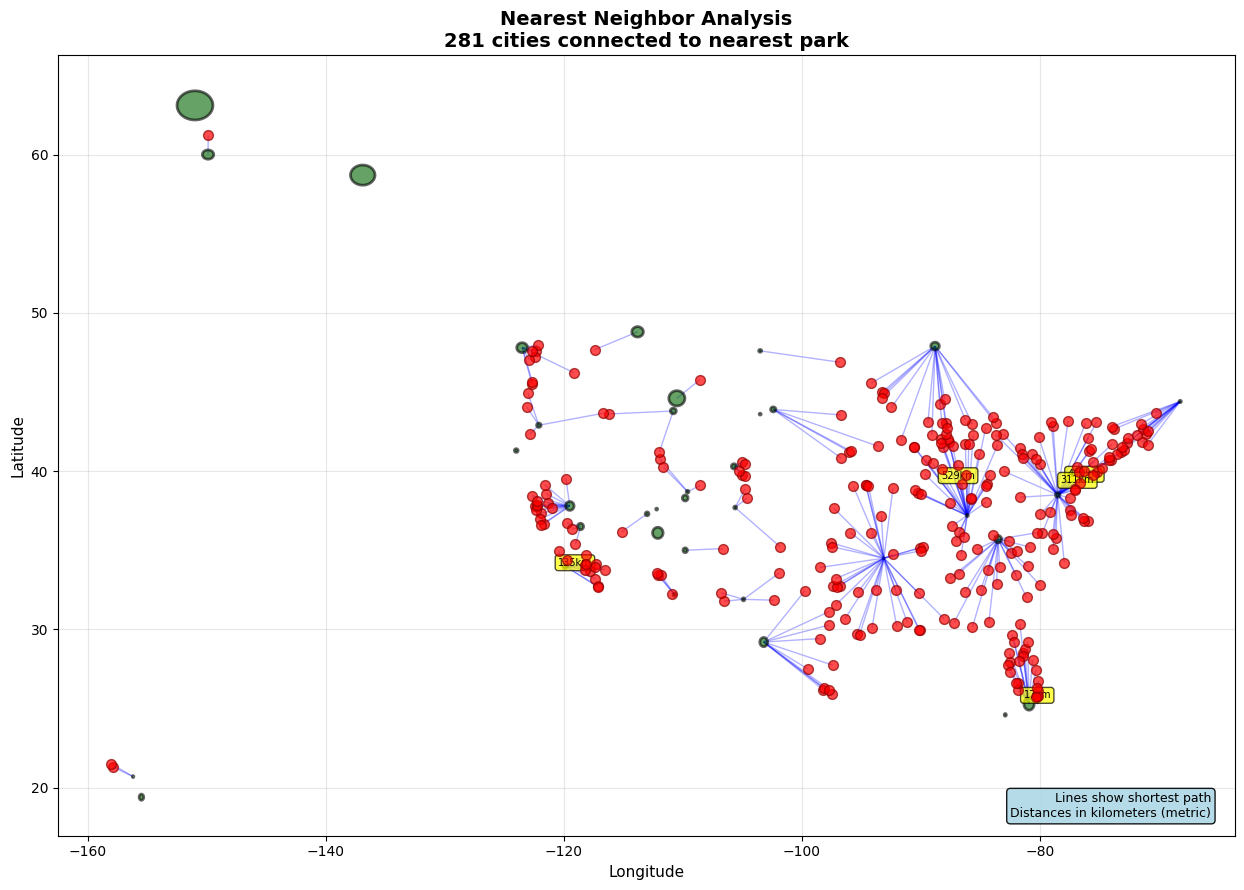

🎯 Nearest neighbor analysis complete:
   Connected 281 cities to their nearest parks
   Distances calculated using Albers Equal Area projection


In [5]:
# Draw lines from each city to nearest park (with metric distances)
fig, ax = plt.subplots(figsize=(14, 9))

# Plot parks
parks.plot(ax=ax, alpha=0.6, color='darkgreen', edgecolor='black', linewidth=2, label='National Parks', zorder=2)

# Transform for accurate distance calculation
cities_proj = cities.to_crs('EPSG:5070')
parks_proj = parks.to_crs('EPSG:5070')

# Draw lines from each city to nearest park
lines_drawn = 0
for idx, city in cities.iterrows():
    city_proj = cities_proj.loc[idx]
    
    # Find nearest park (using projected CRS for accurate distance)
    distances = parks_proj.geometry.distance(city_proj.geometry)
    nearest_idx = distances.idxmin()
    nearest_park = parks.loc[nearest_idx]
    nearest_dist_m = distances.min()
    
    # Get park centroid for cleaner visualization
    park_point = nearest_park.geometry.centroid
    
    # Draw line (in WGS84 for display)
    line = LineString([
        (city.geometry.x, city.geometry.y),
        (park_point.x, park_point.y)
    ])
    
    gpd.GeoSeries([line]).plot(ax=ax, color='blue', alpha=0.3, linewidth=1, zorder=1)
    lines_drawn += 1
    
    # Limit labels to avoid clutter
    if lines_drawn <= 5:
        mid_x = (city.geometry.x + park_point.x) / 2
        mid_y = (city.geometry.y + park_point.y) / 2
        ax.text(mid_x, mid_y, f'{nearest_dist_m/1000:.0f}km', 
               fontsize=7, ha='center', 
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Plot cities on top
cities.plot(ax=ax, color='red', markersize=50, alpha=0.7, edgecolor='darkred', linewidth=1, zorder=3, label='Cities')

ax.set_title(f"Nearest Neighbor Analysis\n{len(cities)} cities connected to nearest park", 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.grid(True, alpha=0.3)

ax.text(0.98, 0.02, 
       "Lines show shortest path\nDistances in kilometers (metric)",
       transform=ax.transAxes,
       ha='right', va='bottom',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9),
       fontsize=9)

plt.tight_layout()
plt.show()

print("🎯 Nearest neighbor analysis complete:")
print(f"   Connected {lines_drawn} cities to their nearest parks")
print("   Distances calculated using Albers Equal Area projection")



### 🏗️ Step 6: Building the Complete Function

Now let's put everything together into a reusable function. This is what you will implement in `src/geopandas_basics.py`.

In [6]:
import geopandas as gpd
from typing import Dict, Any

def spatial_relationships(
    gdf1: gpd.GeoDataFrame,
    gdf2: gpd.GeoDataFrame,
    relationship: str = 'intersects'
) -> Dict[str, Any]:
    """
    Test spatial relationships between two GeoDataFrames.
    
    Supports spatial predicates:
    - 'intersects': Geometries that intersect
    - 'contains': Geometries from gdf1 that contain gdf2
    - 'within': Geometries from gdf1 within gdf2
    - 'distance': Calculate distances between geometries
    - 'nearest': Find nearest features
    
    Args:
        gdf1: First GeoDataFrame
        gdf2: Second GeoDataFrame
        relationship: Type of spatial relationship to test
        
    Returns:
        Dictionary containing:
        - 'relationship': Type of relationship tested
        - 'results': Boolean series or distance measurements
        - 'count': Number of features meeting criteria
        - 'indices': Indices of matching features
        
    Raises:
        ValueError: If inputs are invalid or CRS don't match
        
    Example:
        >>> # Find cities that intersect countries
        >>> result = spatial_relationships(cities, countries, 'intersects')
        >>> print(f"{result['count']} cities intersect countries")
        
        >>> # Calculate distances
        >>> result = spatial_relationships(points, lines, 'distance')
        >>> distances = result['results']
    """
    # Validate inputs
    if not isinstance(gdf1, gpd.GeoDataFrame) or not isinstance(gdf2, gpd.GeoDataFrame):
        raise ValueError("Both inputs must be GeoDataFrames")
    
    # Check CRS compatibility
    if gdf1.crs != gdf2.crs:
        raise ValueError(
            f"CRS mismatch: gdf1 has {gdf1.crs}, gdf2 has {gdf2.crs}. "
            "Transform to same CRS before testing relationships."
        )
    
    # Validate relationship type
    valid_relationships = ['intersects', 'contains', 'within', 'distance', 'nearest']
    if relationship not in valid_relationships:
        raise ValueError(
            f"Invalid relationship '{relationship}'. "
            f"Must be one of: {', '.join(valid_relationships)}"
        )
    
    result = {'relationship': relationship}
    
    if relationship == 'intersects':
        # Test which geometries from gdf1 intersect any geometry in gdf2
        intersects_any = gdf1.geometry.apply(
            lambda geom: gdf2.geometry.intersects(geom).any()
        )
        result['results'] = intersects_any
        result['count'] = int(intersects_any.sum())
        result['indices'] = intersects_any[intersects_any].index.tolist()
        
    elif relationship == 'contains':
        # Test which geometries from gdf1 contain any geometry from gdf2
        contains_any = gdf1.geometry.apply(
            lambda geom: gdf2.geometry.within(geom).any()
        )
        result['results'] = contains_any
        result['count'] = int(contains_any.sum())
        result['indices'] = contains_any[contains_any].index.tolist()
        
    elif relationship == 'within':
        # Test which geometries from gdf1 are within any geometry from gdf2
        within_any = gdf1.geometry.apply(
            lambda geom: gdf2.geometry.contains(geom).any()
        )
        result['results'] = within_any
        result['count'] = int(within_any.sum())
        result['indices'] = within_any[within_any].index.tolist()
        
    elif relationship == 'distance':
        # Calculate minimum distance (convert to metric CRS first)
        gdf1_proj = gdf1.to_crs('EPSG:5070')  # Albers Equal Area
        gdf2_proj = gdf2.to_crs('EPSG:5070')
        
        min_distances_m = gdf1_proj.geometry.apply(
            lambda geom: gdf2_proj.geometry.distance(geom).min()
        )
        min_distances_km = min_distances_m / 1000  # Convert to km
        result['results'] = min_distances_km
        result['distances'] = min_distances_km
        result['count'] = len(min_distances_km)
        result['mean_distance'] = float(min_distances_km.mean())
        result['units'] = 'kilometers'
        
    elif relationship == 'nearest':
        # Find nearest feature (using metric CRS for accurate distances)
        gdf1_proj = gdf1.to_crs('EPSG:5070')
        gdf2_proj = gdf2.to_crs('EPSG:5070')
        
        nearest_indices = []
        nearest_distances = []
        
        for geom1 in gdf1_proj.geometry:
            distances = gdf2_proj.geometry.distance(geom1)
            nearest_idx = distances.idxmin()
            nearest_dist_km = distances.min() / 1000  # Convert to km
            nearest_indices.append(nearest_idx)
            nearest_distances.append(nearest_dist_km)
        
        result['results'] = nearest_indices
        result['nearest_indices'] = nearest_indices
        result['nearest_distances'] = nearest_distances
        result['count'] = len(nearest_indices)
        result['units'] = 'kilometers'
    
    return result

### ✨ Step 7: Test Your Function

Let's test our complete function with different scenarios:

In [7]:
# Test 1: Intersects
print("Test 1: Intersects relationship")
result = spatial_relationships(cities, ecoregions, 'intersects')
print(f"✅ Relationship: {result['relationship']}")
print(f"✅ Matches found: {result['count']}")
print(f"✅ Matching indices: {result['indices'][:5]} (first 5 shown)")
print()

# Test 2: Within
print("Test 2: Within relationship")
result = spatial_relationships(cities, ecoregions, 'within')
print(f"✅ Relationship: {result['relationship']}")
print(f"✅ Matches found: {result['count']}")
print(f"✅ Matching indices: {result['indices'][:5]} (first 5 shown)")
print()

# Test 3: Contains
print("Test 3: Contains relationship")
result = spatial_relationships(ecoregions, cities, 'contains')
print(f"✅ Relationship: {result['relationship']}")
print(f"✅ Matches found: {result['count']}")
print()

# Test 4: Distance
print("Test 4: Distance calculation")
result = spatial_relationships(cities, parks, 'distance')
print(f"✅ Relationship: {result['relationship']}")
print(f"✅ Mean distance: {result['mean_distance']:.2f} {result['units']}")
print(f"✅ Number of distances calculated: {result['count']}")
print()

# Test 5: Nearest neighbor
print("Test 5: Nearest neighbor analysis")
result = spatial_relationships(cities, parks, 'nearest')
print(f"✅ Relationship: {result['relationship']}")
print(f"✅ Nearest features found: {result['count']}")
print(f"✅ Example nearest indices: {result['nearest_indices'][:5]}")
print()

# Test 6: Error handling (invalid relationship)
print("Test 6: Error handling - invalid relationship")
try:
    spatial_relationships(cities, ecoregions, 'invalid_relationship')
except ValueError as e:
    print(f"✅ Correctly raised ValueError: {e}")
print()

# Test 7: Error handling (CRS mismatch)
print("Test 7: Error handling - CRS mismatch")
try:
    cities_proj = cities.to_crs('EPSG:5070')
    spatial_relationships(cities_proj, ecoregions, 'intersects')
except ValueError as e:
    print(f"✅ Correctly raised ValueError: {e}")

print()
print("🎉 All tests completed!")

Test 1: Intersects relationship
✅ Relationship: intersects
✅ Matches found: 68
✅ Matching indices: [1, 11, 12, 13, 14] (first 5 shown)

Test 2: Within relationship
✅ Relationship: within
✅ Matches found: 68
✅ Matching indices: [1, 11, 12, 13, 14] (first 5 shown)

Test 3: Contains relationship
✅ Relationship: contains
✅ Matches found: 20

Test 4: Distance calculation
✅ Relationship: distance
✅ Mean distance: 326.09 kilometers
✅ Number of distances calculated: 281

Test 5: Nearest neighbor analysis
✅ Relationship: nearest
✅ Nearest features found: 281
✅ Example nearest indices: [27, 5, 25, 29, 27]

Test 6: Error handling - invalid relationship
✅ Correctly raised ValueError: Invalid relationship 'invalid_relationship'. Must be one of: intersects, contains, within, distance, nearest

Test 7: Error handling - CRS mismatch
✅ Correctly raised ValueError: CRS mismatch: gdf1 has EPSG:5070, gdf2 has EPSG:4326. Transform to same CRS before testing relationships.

🎉 All tests completed!


### 🧪 Step 8: Verify with Pytest

After implementing in `src/geopandas_basics.py`, run the tests:

```bash
uv run pytest tests/test_geopandas_basics.py::TestSpatialRelationships -v
```

**⚠️ IMPORTANT: Make sure this passes before you move on!**

---

### 🔑 Key Learning Points

- **`intersects`** tests whether features overlap or touch
- **`within`** and **`contains`** test nested spatial relationships
- Distance calculations should use a **projected CRS** for accurate metric results
- **Nearest neighbor** analysis helps identify the closest feature in another dataset
- Spatial relationship functions often return both **results** and **summary information**
- CRS matching is essential before running most spatial relationship tests
- Topology helps describe how features relate to each other in space